





# Landlab deposition test for simple to know how it works

Erosion-Deposition model in the style of Davy and Lague (2009).

Erosion-Deposition model in the style of Davy and Lague (2009). It uses a
mass balance approach across the total sediment mass both in the bed and
in transport coupled with explicit representation of the sediment
transport lengthscale (the "xi-q" model) to derive a range of erosional
and depositional responses in river channels.

This implementation is close to the Davy & Lague scheme, with a few
deviations:

* A fraction of the eroded sediment is permitted to enter the wash load,
  and lost to the mass balance (``F_f``).
* Here an incision threshold ``omega`` is permitted, where it was not by Davy &
  Lague. It is implemented with an exponentially smoothed form to prevent
  discontinuities in the parameter space. See the
  :py:class:`~landlab.components.StreamPowerSmoothThresholdEroder`
  for more documentation.
* This component uses an "effective" settling velocity, ``v_s``, as one of its
  inputs. This parameter is simply equal to Davy & Lague's ``d_star * V``
  dimensionless number.

Erosion of the bed follows a stream power formulation, i.e.::

    E = K * q**m_sp * S**n_sp - omega
  ...
      [ 2.04 , -0.065, -0.065, -0.053,  6.026],
      [ 3.059, -0.054, -0.053, -0.035,  7.053],
      [ 4.059,  5.041,  6.07 ,  7.004,  8.01 ]])

Note that the transition between transport-limited and detachment-limited
behavior is controlled by the dimensionless ratio (``v_s / r``) where ``r`` is the
runoff ratio (``Q=Ar``). ``r`` can be changed in the flow accumulation component
but is not changed within ErosionDeposition. Because the runoff ratio ``r``
is not changed within the ErosionDeposition component, ``v_s`` becomes the
parameter that fundamentally controls response style. Very small ``v_s`` will
lead to a detachment-limited response style, very large ``v_s`` will lead to a
transport-limited response style. ``v_s == 1`` means equal contributions from
transport and erosion, and a hybrid response as described by Davy & Lague.

Unlike other some other fluvial erosion components in Landlab, in this
component (and :py:class:`~landlab.components.SPACE`) no erosion occurs
in depressions or in areas with adverse slopes. There is no ability to
pass a keyword argument ``erode_flooded_nodes``.

If depressions are handled (as indicated by the presence of the field
``"flood_status_code"`` at nodes), then deposition occurs throughout the
depression and sediment is passed out of the depression. Where pits are
encountered, then all sediment is deposited at that node only.

Component written by C. Shobe, K. Barnhart, and G. Tucker.

References
----------
**Required Software Citation(s) Specific to this Component**

Barnhart, K., Glade, R., Shobe, C., Tucker, G. (2019). Terrainbento 1.0: a
Python package for multi-model analysis in long-term drainage basin
evolution. Geoscientific Model Development  12(4), 1267--1297.
https://dx.doi.org/10.5194/gmd-12-1267-2019

**Additional References**

Davy, P., Lague, D. (2009). Fluvial erosion/transport equation of landscape
evolution models revisited Journal of Geophysical Research  114(F3),
F03007. https://dx.doi.org/10.1029/2008jf001146


In [1]:
import copy

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

from landlab import HexModelGrid
from landlab.components import ErosionDeposition, FlowAccumulator
from landlab.plot import imshow_grid

## Set some parameters:

In [3]:
# Parameters
nrows = 41
ncols = 41
dx = 100.0
K = 0.0001  # erodibility coefficient, 1/yr
m_sp = 0.5  # exponent on drainage area or discharge, -
n_sp = 1.0  # exponent on slope, -
sp_crit = 0.0  # erosion threshold
v_s = 100.0  # settling velocity parameter (dimensionless if drainage area is used instead of discharge)
F_f = 0.5  # fraction of fines generated during bed erosion
initial_elevation = (
    200.0  # starting elevation of an "uplifted block" (rapid baselevel drop), m
)

run_duration = 120000.0  # duration of run, yr
dt = 100.0  # time-step duration, yr
plot_every = 40000.0  # time interval for plotting, yr

# Derived parameters
nsteps = int(run_duration / dt)
next_plot = plot_every

# set up colormap
cmap = copy.copy(mpl.colormaps["pink"])


## Create a grid with one side open:

In [4]:
mg = HexModelGrid(
    (nrows, ncols), spacing=dx, node_layout="rect", orientation="vertical"
)
z = mg.add_zeros("topographic__elevation", at="node")
# add some roughness, as this lets "natural" channel planforms arise
np.random.seed(0)
initial_roughness = np.random.rand(z.size)
z[:] += initial_roughness
z[mg.core_nodes] += initial_elevation
z[mg.boundary_nodes] = 0.0

# close off boundaries on 3 sides
is_closed_boundary = np.logical_and(
    mg.status_at_node != mg.BC_NODE_IS_CORE,
    mg.x_of_node < (np.amax(mg.x_of_node) - 0.5 * dx),
)
mg.status_at_node[is_closed_boundary] = mg.BC_NODE_IS_CLOSED

## Instantiate components:

In [5]:
fr = FlowAccumulator(mg, depression_finder="DepressionFinderAndRouter")
ed = ErosionDeposition(
    mg,
    K=K,
    m_sp=m_sp,
    n_sp=n_sp,
    sp_crit=sp_crit,
    v_s=v_s,
    F_f=F_f,
    solver="adaptive",  # use the adaptive time stepper, which is slightly faster
)

## Run the model in a loop to evolve topography on the uplifted block:

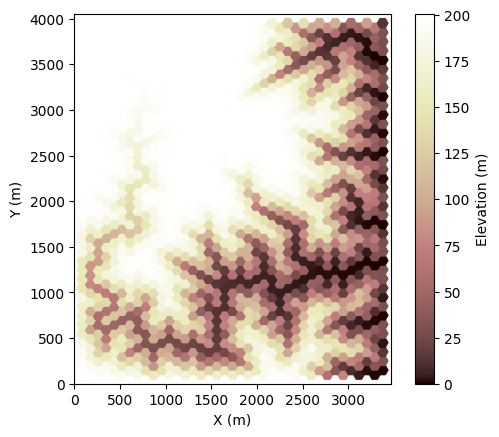

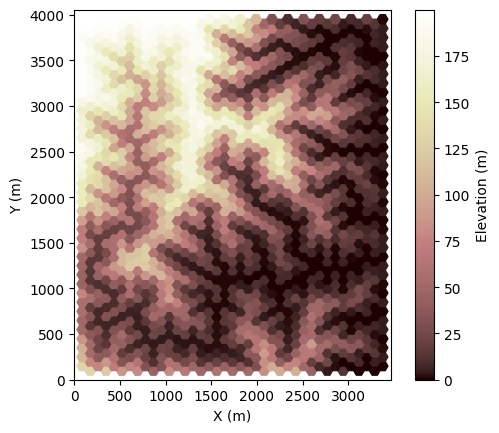

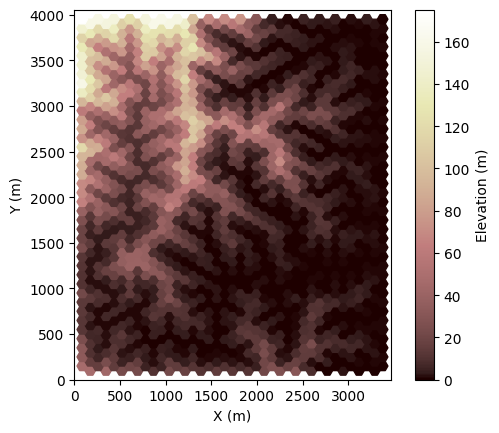

In [6]:
for i in range(1, nsteps + 1):
    # route flow
    fr.run_one_step()  # run_one_step isn't time sensitive, so it doesn't take dt as input

    # do some erosion/deposition
    ed.run_one_step(dt)

    if i * dt >= next_plot:
        plt.figure()
        imshow_grid(
            mg,
            "topographic__elevation",
            grid_units=["m", "m"],
            var_name="Elevation (m)",
            cmap=cmap,
        )
        next_plot += plot_every

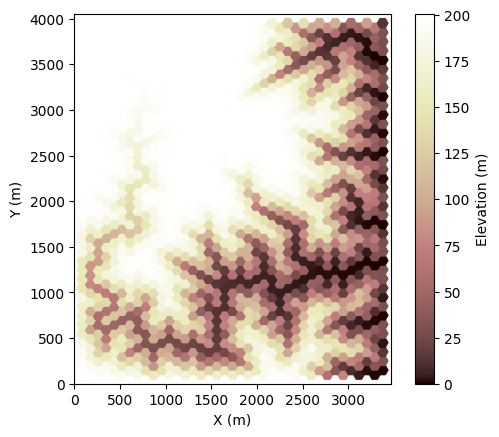

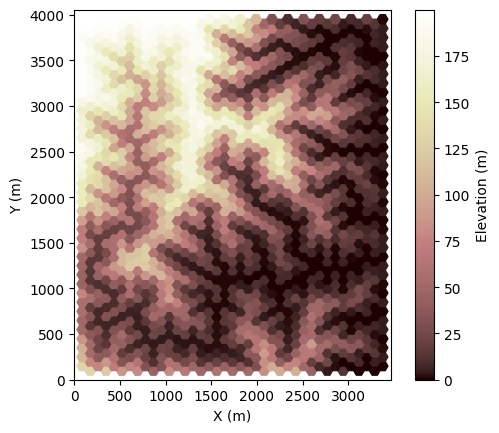

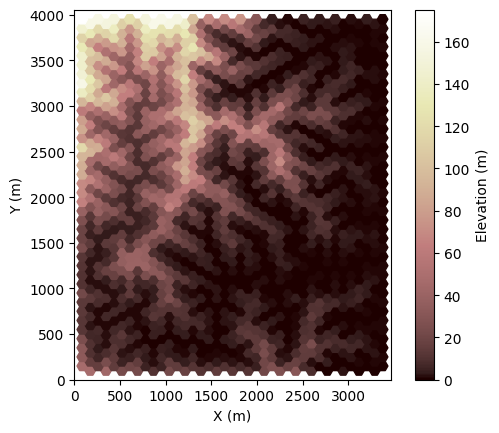

In [9]:
import copy

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

from landlab import HexModelGrid
from landlab.components import ErosionDeposition, FlowAccumulator
from landlab.plot import imshow_grid

# Parameters
nrows = 41
ncols = 41
dx = 100.0
K = 0.0001  # erodibility coefficient, 1/yr
m_sp = 0.5  # exponent on drainage area or discharge, -
n_sp = 1.0  # exponent on slope, -
sp_crit = 0.0  # erosion threshold
v_s = 100.0  # settling velocity parameter (dimensionless if drainage area is used instead of discharge)
F_f = 0.5  # fraction of fines generated during bed erosion
initial_elevation = (
    200.0  # starting elevation of an "uplifted block" (rapid baselevel drop), m
)

run_duration = 120000.0  # duration of run, yr
dt = 100.0  # time-step duration, yr
plot_every = 40000.0  # time interval for plotting, yr

# Derived parameters
nsteps = int(run_duration / dt)
next_plot = plot_every

# set up colormap
cmap = copy.copy(mpl.colormaps["pink"])

mg = HexModelGrid(
    (nrows, ncols), spacing=dx, node_layout="rect", orientation="vertical"
)
z = mg.add_zeros("topographic__elevation", at="node")
# add some roughness, as this lets "natural" channel planforms arise
np.random.seed(0)
initial_roughness = np.random.rand(z.size)
z[:] += initial_roughness
z[mg.core_nodes] += initial_elevation
z[mg.boundary_nodes] = 0.0

# close off boundaries on 3 sides
is_closed_boundary = np.logical_and(
    mg.status_at_node != mg.BC_NODE_IS_CORE,
    mg.x_of_node < (np.amax(mg.x_of_node) - 0.5 * dx),
)
mg.status_at_node[is_closed_boundary] = mg.BC_NODE_IS_CLOSED

fr = FlowAccumulator(mg, depression_finder="DepressionFinderAndRouter")
ed = ErosionDeposition(
    mg,
    K=K,
    m_sp=m_sp,
    n_sp=n_sp,
    sp_crit=sp_crit,
    v_s=v_s,
    F_f=F_f,
    solver="adaptive",  # use the adaptive time stepper, which is slightly faster
)

z_initial = z.copy()
z_middle = None
z_final = None

middle_step = nsteps // 2

for i in range(1, nsteps + 1):
    # route flow
    fr.run_one_step()  # run_one_step isn't time sensitive, so it doesn't take dt as input

    # do some erosion/deposition
    ed.run_one_step(dt)

    if i == middle_step:
        z_middle = z.copy()

    if i == nsteps:
        z_final = z.copy()

    if i * dt >= next_plot:
        plt.figure()
        imshow_grid(
            mg,
            "topographic__elevation",
            grid_units=["m", "m"],
            var_name="Elevation (m)",
            cmap=cmap,
        )
        next_plot += plot_every

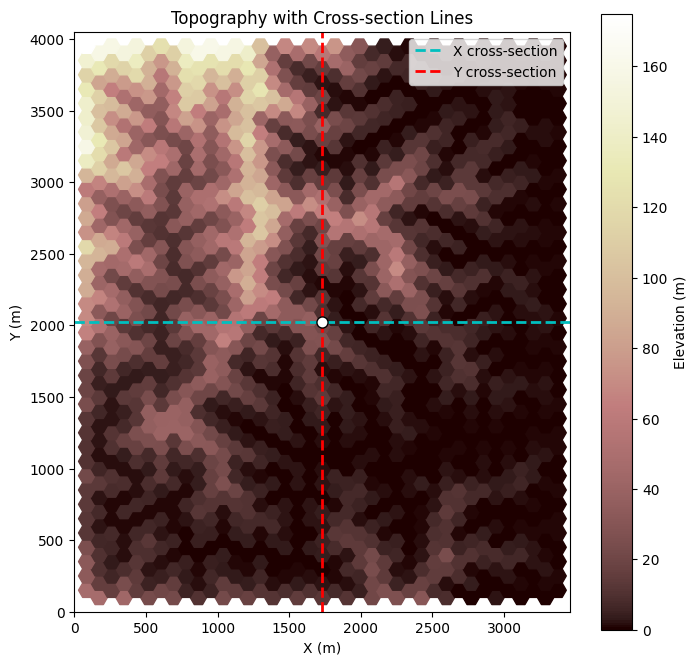

In [12]:
plt.figure(figsize=(8, 8))

imshow_grid(
    mg,
    "topographic__elevation",
    grid_units=["m", "m"],
    var_name="Elevation (m)",
    cmap=cmap,
)

# Coordinates of the center
xmid = 0.5 * (mg.x_of_node.min() + mg.x_of_node.max())
ymid = 0.5 * (mg.y_of_node.min() + mg.y_of_node.max())

# Horizontal cross section (parallel to x-axis)
plt.plot(
    [mg.x_of_node.min(), mg.x_of_node.max()],
    [ymid, ymid],
    "c--",
    lw=2,
    label="X cross-section",
)

# Vertical cross section (parallel to y-axis)
plt.plot(
    [xmid, xmid],
    [mg.y_of_node.min(), mg.y_of_node.max()],
    "r--",
    lw=2,
    label="Y cross-section",
)

# Mark their intersection
plt.plot(xmid, ymid, "wo", ms=8, mec="k")

plt.legend()
plt.title("Topography with Cross-section Lines")
plt.show()

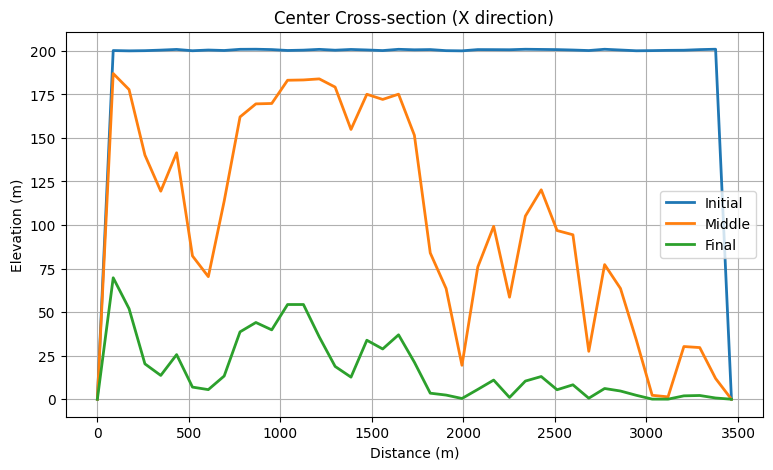

In [10]:
tol = dx / 2.0

xmid = 0.5 * (mg.x_of_node.min() + mg.x_of_node.max())
ymid = 0.5 * (mg.y_of_node.min() + mg.y_of_node.max())

mask = np.abs(mg.y_of_node - ymid) < tol

x = mg.x_of_node[mask]
order = np.argsort(x)

plt.figure(figsize=(9,5))

plt.plot(
    x[order],
    z_initial[mask][order],
    label="Initial",
    lw=2,
)

plt.plot(
    x[order],
    z_middle[mask][order],
    label="Middle",
    lw=2,
)

plt.plot(
    x[order],
    z_final[mask][order],
    label="Final",
    lw=2,
)

plt.xlabel("Distance (m)")
plt.ylabel("Elevation (m)")
plt.title("Center Cross-section (X direction)")
plt.grid(True)
plt.legend()

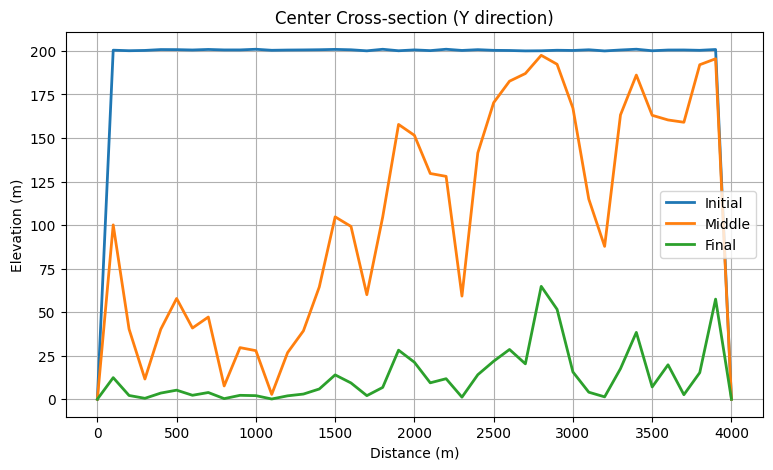

In [11]:
mask = np.abs(mg.x_of_node - xmid) < tol

y = mg.y_of_node[mask]
order = np.argsort(y)

plt.figure(figsize=(9,5))

plt.plot(
    y[order],
    z_initial[mask][order],
    label="Initial",
    lw=2,
)

plt.plot(
    y[order],
    z_middle[mask][order],
    label="Middle",
    lw=2,
)

plt.plot(
    y[order],
    z_final[mask][order],
    label="Final",
    lw=2,
)

plt.xlabel("Distance (m)")
plt.ylabel("Elevation (m)")
plt.title("Center Cross-section (Y direction)")
plt.grid(True)
plt.legend()

Text(0.5, 1.0, 'Deposition during one timestep')

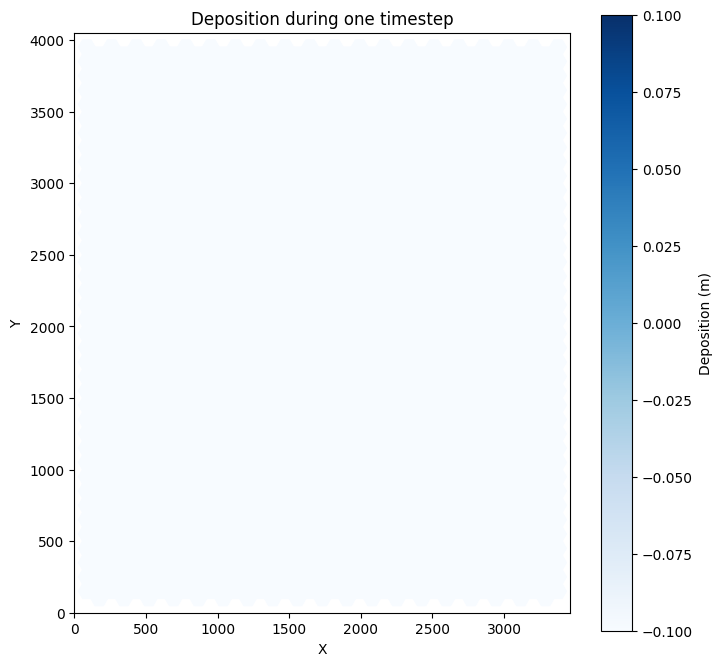

In [13]:
z_before = z.copy()
ed.run_one_step(dt)

dz = z - z_before
deposition = np.where(dz > 0, dz, np.nan)

plt.figure(figsize=(8,8))

imshow_grid(
    mg,
    deposition,
    cmap="Blues",
    colorbar_label="Deposition (m)",
)

plt.title("Deposition during one timestep")

Text(0.5, 1.0, 'Net deposition')

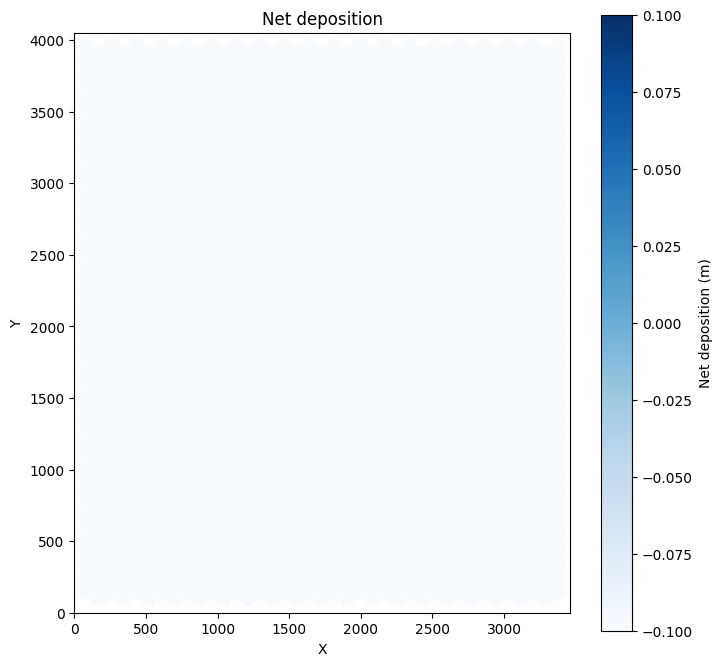

In [14]:
total_change = z - z_initial
deposition = np.where(total_change > 0, total_change, np.nan)

plt.figure(figsize=(8,8))

imshow_grid(
    mg,
    deposition,
    cmap="Blues",
    colorbar_label="Net deposition (m)",
)

plt.title("Net deposition")


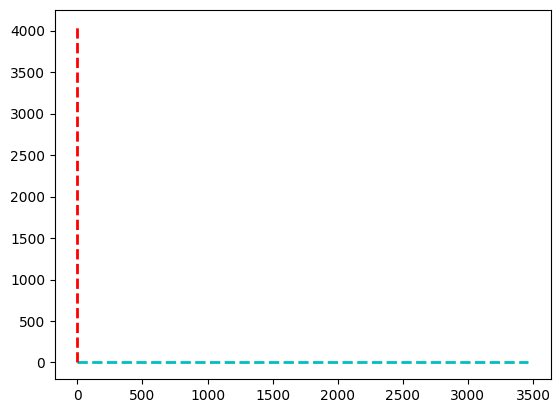

In [16]:
dep = np.where(total_change > 0, total_change, 0)

imax = np.argmax(dep)

x_dep = mg.x_of_node[imax]
y_dep = mg.y_of_node[imax]

plt.plot(
    [mg.x_of_node.min(), mg.x_of_node.max()],
    [y_dep, y_dep],
    'c--',
    lw=2
)

plt.plot(
    [x_dep, x_dep],
    [mg.y_of_node.min(), mg.y_of_node.max()],
    'r--',
    lw=2
)

In [17]:
drainage_area = mg.at_node["drainage_area"]

boundary = mg.boundary_nodes
outlet = boundary[np.argmax(drainage_area[boundary])]

print("Outlet:", outlet)

Outlet: 553


In [18]:
receivers = mg.at_node["flow__receiver_node"]
area = mg.at_node["drainage_area"]

channel = [outlet]
current = outlet

while True:

    donors = np.where(receivers == current)[0]

    # remove self-reference
    donors = donors[donors != current]

    if len(donors) == 0:
        break

    # choose largest tributary
    current = donors[np.argmax(area[donors])]

    channel.append(current)

channel = np.array(channel)

print("Number of channel nodes:", len(channel))

Number of channel nodes: 94


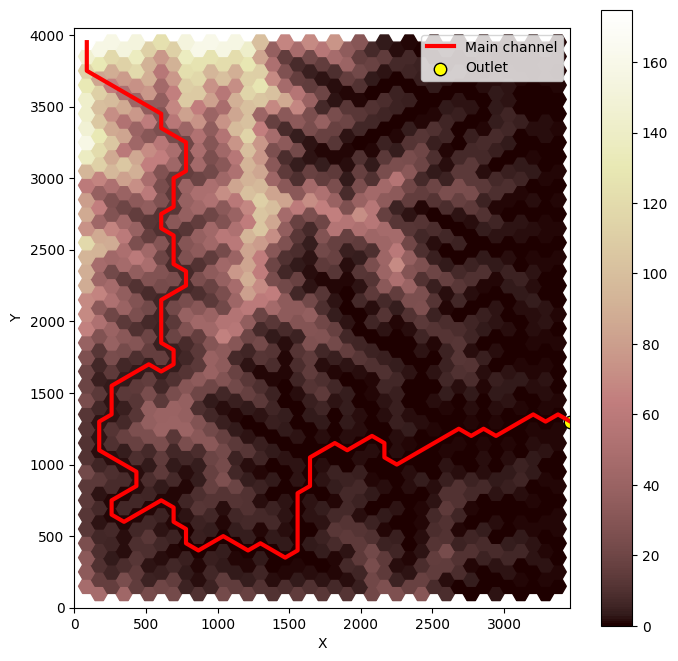

In [19]:
plt.figure(figsize=(8,8))

imshow_grid(
    mg,
    "topographic__elevation",
    cmap=cmap,
)

plt.plot(
    mg.x_of_node[channel],
    mg.y_of_node[channel],
    "r-",
    lw=3,
    label="Main channel",
)

plt.scatter(
    mg.x_of_node[outlet],
    mg.y_of_node[outlet],
    c="yellow",
    s=80,
    edgecolors="k",
    label="Outlet",
)

plt.legend()
plt.show()

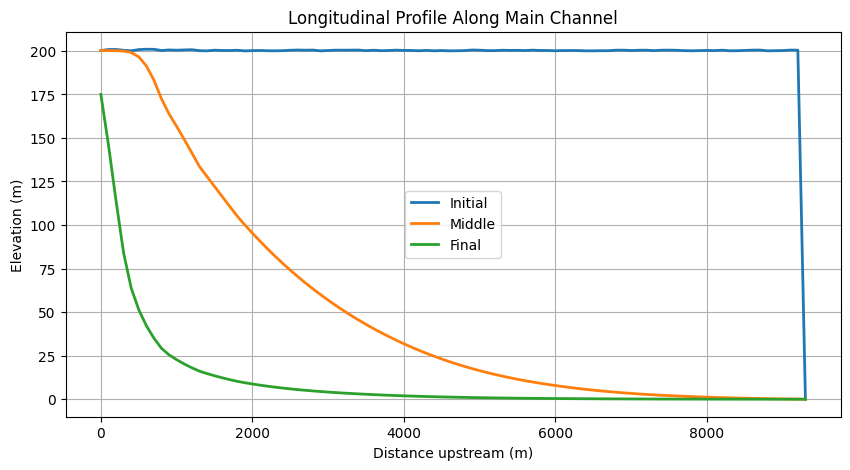

In [22]:
channel = channel[::-1]

x = mg.x_of_node[channel]
y = mg.y_of_node[channel]

distance = np.zeros(len(channel))

for i in range(1, len(channel)):
    dx = x[i] - x[i-1]
    dy = y[i] - y[i-1]
    distance[i] = distance[i-1] + np.sqrt(dx**2 + dy**2)

z_initial
z_middle
z_final

plt.figure(figsize=(10,5))

plt.plot(distance, z_initial[channel], label="Initial", lw=2)
plt.plot(distance, z_middle[channel], label="Middle", lw=2)
plt.plot(distance, z_final[channel], label="Final", lw=2)

plt.xlabel("Distance upstream (m)")
plt.ylabel("Elevation (m)")
plt.title("Longitudinal Profile Along Main Channel")

plt.grid(True)
plt.legend()
plt.show()

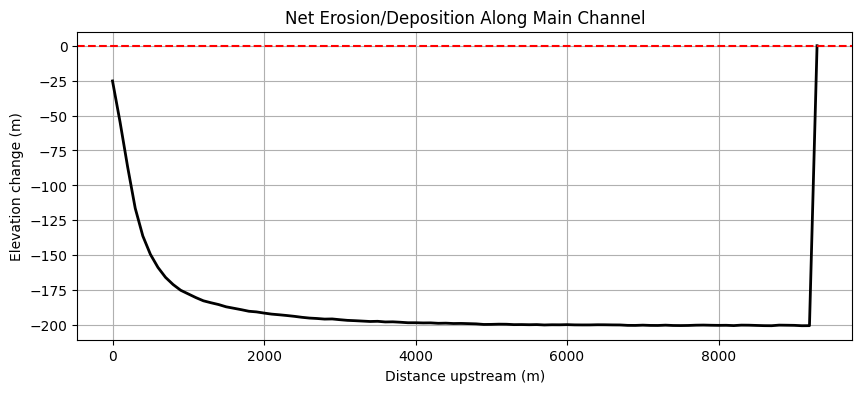

In [23]:
dz = z_final - z_initial

plt.figure(figsize=(10,4))

plt.plot(distance, dz[channel], "k", lw=2)
plt.axhline(0, color="red", ls="--")

plt.xlabel("Distance upstream (m)")
plt.ylabel("Elevation change (m)")
plt.title("Net Erosion/Deposition Along Main Channel")

plt.grid(True)